# HW 2 - Convolutional Neural Networks (CNNs)

## Google Colab [Optional]

If you are using Google Colab, configure and run the cell below to mount your Google Drive and set up the correct working directory for the assignment. You may ignore this cell if you are working locally.

In [ ]:
from google.colab import drive
import os

# 1. Mounting Google Drive: This allows Colab to access files in your Google Drive
drive.mount('/content/drive')

# 2. Tell Colab where to find your assignment files and where to save your work

# TODO: Enter the relative path in your Google Drive of the assignment.
# FOLDERNAME = "hw2_student_version" # e.g. 'cs7643/ps0/'
FOLDERNAME = "Deep Learning Homework/hw2"

assert FOLDERNAME is not None, "[!] Enter the foldername."

FULL_PATH = "/content/drive/MyDrive/" + FOLDERNAME
assert os.path.exists(FULL_PATH), "Make sure your FOLDERNAME is correct"

In [ ]:
%cd $FULL_PATH

In [ ]:
!ls "/content/drive/MyDrive/Deep Learning Homework"

In [ ]:
!uv pip install -r requirements.txt --no-progress

## Part1: Implementing CNN from Scratch

In [6]:
PART_ONE_FULL_PATH = FULL_PATH + "/part1-convnet/"

In [ ]:
%cd $PART_ONE_FULL_PATH

### Load CIFAR-10 data

In [ ]:
%cd data
!python get_data.py
%cd ..

### Cross-check your implementation

In [ ]:
# uncomment to run individual tests
!python -m pytest tests/test_conv.py -v
!python -m pytest tests/test_linear.py -v
!python -m pytest tests/test_maxpool.py -v
!python -m pytest tests/test_relu.py -v
!python -m pytest tests/test_sgd.py -v

In [ ]:
# run all tests
!python -m pytest tests -v

### Train your ConvNet

In [ ]:
!python train.py

In [18]:
from utils import load_training_curve

### Visualize Part-1 training curve

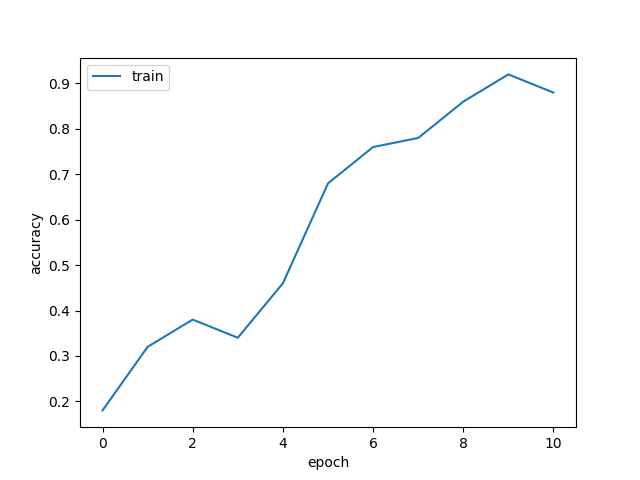

In [19]:
load_training_curve("./train.png")

## Part2: PyTorch

In [20]:
PART_TWO_FULL_PATH = FULL_PATH + "/part2-pytorch/"

In [ ]:
%cd $PART_TWO_FULL_PATH

### Load CIFAR-10 data

In [ ]:
%cd data
!python get_data.py
%cd ..

### Train your Two-Layer Net

In [ ]:
!python main.py --config configs/config_twolayer.yaml

### Train your Vanilla ConvNet

In [ ]:
!python main.py --config configs/config_vanilla_cnn.yaml

In [ ]:
# uncomment to run individual tests
!python -m pytest tests/test_twolayer.py -v
!python -m pytest tests/test_vanilla_cnn.py -v

In [ ]:
# run all tests
!python -m pytest tests -v

### Train your own model

In [ ]:
!python main.py --config configs/config_mymodel.yaml

# **Assignment 2 Writeup**

- Name: `Venkata Aashutosh Aripirala`
- GT Email: `av84@gatech.edu`
- GT ID: `904173725`



Plot the training curve for Part-1.

/content/drive/MyDrive/Deep Learning Homework/hw2/part1-convnet


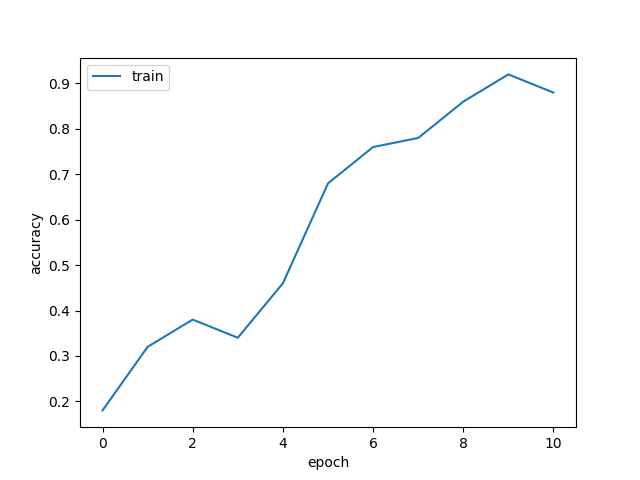

In [40]:
%cd $PART_ONE_FULL_PATH
from utils import load_training_curve
load_training_curve("./train.png")

Briefly describe your design for the architecture of MyModel. What are the key components/characteristics that make it work?

MyModel, as I architected it, is a convolutional neural network designed with two sequential convolutional blocks followed by a fully connected classification head:


Dual-Stage Feature Extractor: The first block uses two 3×3 convolutional layers (32 channels), and the second block doubles the capacity to 64 channels across two more 3×3 layers. Small 3×3 filters maintain a large effective receptive field while keeping parameter count and compute low.


Batch Norm: Applied after every convolutional layer and before the final classification layer. BatchNorm stabilizes internal covariate shift, enabling faster convergence and allowing the use of higher learning rates, which I had to resort to after a few experiments, considering the pace of learning in SGD.


Spatial Downsampling: A 2×2 MaxPool layer (stride 2) at the end of each block reduces spatial dimensions (32×32→16×16→8×8), condensing feature representations and providing translational invariance.


Regularization: Spatial Dropout2d (0.2 and 0.3) after pooling blocks and standard Dropout (0.5) in the dense layer prevent co-adaptation of features, mitigating overfitting on CIFAR-10.

When designing MyModel, did you try anything i.e. (making the model deeper, adding specific layers/activations, etc.) that didn't end up working in the way you expected? Why might that be?

 Initially, using a very small learning rate (lr=10^−4
 ) with default SGD momentum resulted in almost negligible progress across early epochs, as the gradient updates were too small to overcome the parameter volume introduced by multiple convolutional and batch norm layers. Increasing the learning rate to 0.05 with momentum (0.9) was necessary to escape flat loss regions.

Additionally, experimenting with class-balanced Focal Loss on standard training distributions did not yield expected gains compared to standard Cross-Entropy. My judgement is, because Focal Loss scales loss gradients by (1−p_t)γ, it down-weighted well-classified or moderately confident examples.

On a balanced dataset with diverse classes, this significantly attenuated the overall gradient signal, leading to slower convergence compared to Cross-Entropy unless compensated for with extra efforts in loss scaling or extended training schedules.

## Submission

**IMPORTANT**: Before submitting, please clear all output cells besides the plot for part 1 showing the training curve.

This cell will zip up your code for part 1 and part 2 into separate zip files as well as generate the notebook pdf.

Colab may take some time to update on the cloud file system, so if you find that running this cell does not generate the latest version of your notebook, you can wait a few minutes before trying again, or just download the notebook and run the command locally.

In [ ]:
# on colab, you may need to install chromium to convert the notebook to pdf
!playwright install-deps chromium
!playwright install chromium

In [42]:
%cd $FULL_PATH
!python collect_submission.py

/content/drive/MyDrive/Deep Learning Homework/hw2
=== HW2 Submission Collection Script ===

Converting notebook to PDF...
Successfully converted main.ipynb to hw2_notebook_submission.pdf

Creating zip archive...
Created hw2_part1_code_submission.zip
Created hw2_part2_code_submission.zip

=== Submission Collection Complete ===
Generated: hw2_notebook_submission.pdf
Generated: hw2_part1_code_submission.zip
Generated: hw2_part2_code_submission.zip

Please submit these files to Gradescope:
  - hw2_notebook_submission.pdf
  - hw2_part1_code_submission.zip
  - hw2_part2_code_submission.zip

Congratulations on completing the assignment!
